# Introducción al aprendizaje automatizado (O2026)
## Tutorial 14 - Análisis de Supervivencia (*Survival Analysis*)

**Objetivo:**
Aprender a modelar datos de **tiempo-hasta-evento** en Python con `lifelines`, partiendo de la intuición econométrica que ya tienen. Vamos a estimar curvas de supervivencia, compararlas entre grupos y ajustar modelos de regresión que respetan la **censura** de los datos.

### Temario:
- Repaso conceptual: tiempo-hasta-evento, censura y la función de supervivencia $S(t)$
- Estimador de **Kaplan-Meier** y su lectura
- **Test de log-rank** para comparar grupos
- Modelo de **riesgos proporcionales de Cox**
- Una lección sobre **confusión** (*confounding*) con los datos de `Publication`
- Simulación de datos de supervivencia (*Call Center*) y recuperación de parámetros

*Notebook basado en el laboratorio del Capítulo 11 de ISLP (James, Witten, Hastie, Tibshirani & Taylor), adaptado al español.*

---

## Requisitos

Este notebook usa el paquete **`ISLP`**, que ya trae como dependencias `lifelines` (análisis de supervivencia), `pandas`, `numpy`, `matplotlib` y `scikit-learn`. Los datos (`BrainCancer`, `Publication`) vienen incluidos en `ISLP`, así que **no hay que descargar nada externo**.

Si todavía no tenés `ISLP` instalado (por ejemplo, en Google Colab o en un entorno nuevo), descomentá y corré la celda de abajo **una sola vez**:

In [1]:
# Descomentar la primera vez que se corre el notebook:
# %pip install ISLP

## 0. ¿Por qué un método nuevo? La censura

En la magistral y en la intro del Tutorial 13 vimos el problema. Lo recordamos rápido.

Muchas preguntas económicas son sobre **cuánto tiempo pasa hasta que ocurre un evento**:
- ¿Cuánto dura un episodio de **desempleo** hasta que la persona consigue empleo?
- ¿Cuánto **sobrevive** una firma hasta quebrar?
- ¿Cuánto tarda un paciente hasta el alta (o hasta el fallecimiento)?

El problema es que cuando termina el estudio **muchas observaciones todavía no vieron el evento**. Sabemos que una persona lleva 20 meses desempleada, pero no sabemos cuándo conseguirá empleo: solo sabemos que es **más de 20 meses**. Eso es una observación **censurada** (a derecha).

**¿Por qué no usar OLS sobre el tiempo?**
- Si tiramos las censuradas, perdemos información y **sesgamos** la muestra hacia los eventos rápidos.
- Si usamos el tiempo observado como si fuera el tiempo real del evento, **subestimamos** sistemáticamente la duración.

El análisis de supervivencia resuelve esto: usa la información parcial de las censuradas ("sobrevivió **al menos** hasta $t$") sin pretender que conocemos el tiempo final.

### Dos objetos centrales

**Función de supervivencia:** probabilidad de "sobrevivir" (no haber tenido el evento) más allá de $t$.
$$S(t) = \Pr(T > t)$$

**Función de riesgo (*hazard*):** tasa instantánea a la que ocurre el evento en $t$, *dado* que se sobrevivió hasta $t$.
$$h(t) = \lim_{\Delta t \to 0} \frac{\Pr(t \le T < t+\Delta t \mid T \ge t)}{\Delta t}$$

> Intuición del *hazard*: si $h(t)$ es alto, "el evento está por pasar ya". El modelo de Cox modela el *hazard*.

**Convención de codificación del evento (`status`):**
- `status = 1` → el evento **se observó** (ej.: fallecimiento, conseguir empleo).
- `status = 0` → observación **censurada** (terminó el seguimiento sin ver el evento).

## 1. Preparación e importación de librerías

Usamos `lifelines`, la librería estándar de supervivencia en Python, y los datos del paquete `ISLP`.

In [2]:
from matplotlib.pyplot import subplots
import numpy as np
import pandas as pd

from ISLP.models import ModelSpec as MS
from ISLP import load_data
from ISLP.survival import sim_time

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

## 2. Datos de cáncer de cerebro (`BrainCancer`)

`BrainCancer` registra a **88 pacientes** con un tumor cerebral. Las variables clave:

| Variable | Descripción |
|---|---|
| `time` | tiempo de seguimiento (meses) |
| `status` | 1 = fallecimiento observado, 0 = censurado |
| `sex` | sexo del paciente |
| `diagnosis` | tipo de tumor (meningioma, LG glioma, HG glioma, otro) |
| `ki` | índice de Karnofsky (estado funcional) |
| `gtv` | volumen del tumor (*gross tumor volume*) |
| `loc`, `stereo` | localización y método de tratamiento |

In [3]:
BrainCancer = load_data('BrainCancer')
print(BrainCancer.shape)
BrainCancer.columns

(88, 8)


Index(['sex', 'diagnosis', 'loc', 'ki', 'gtv', 'stereo', 'status', 'time'], dtype='object')

In [4]:
BrainCancer.head()

,sex,diagnosis,loc,ki,gtv,stereo,status,time
0,Female,Meningioma,Infratentorial,90,6.11,SRS,0,57.64
1,Male,HG glioma,Supratentorial,90,19.35,SRT,1,8.98
2,Female,Meningioma,Infratentorial,70,7.95,SRS,0,26.46
3,Female,LG glioma,Supratentorial,80,7.61,SRT,1,47.80
4,Male,HG glioma,Supratentorial,90,5.06,SRT,1,6.30


In [5]:
# ¿Cuántos pacientes vieron el evento (fallecimiento) y cuántos están censurados?
BrainCancer['status'].value_counts()

status
0    53
1    35
Name: count, dtype: int64

De los 88 pacientes, **35 fallecieron** durante el seguimiento; el resto está censurado. Si analizáramos solo a esos 35 estaríamos sesgando todo el análisis.

### 2.1. Curva de Kaplan-Meier (toda la muestra)

El **estimador de Kaplan-Meier** es la forma no paramétrica estándar de estimar $S(t)$. Es como un "histograma acumulado" que va bajando escalón a escalón cada vez que ocurre un evento, y maneja la censura de forma automática. No supone ninguna forma funcional.

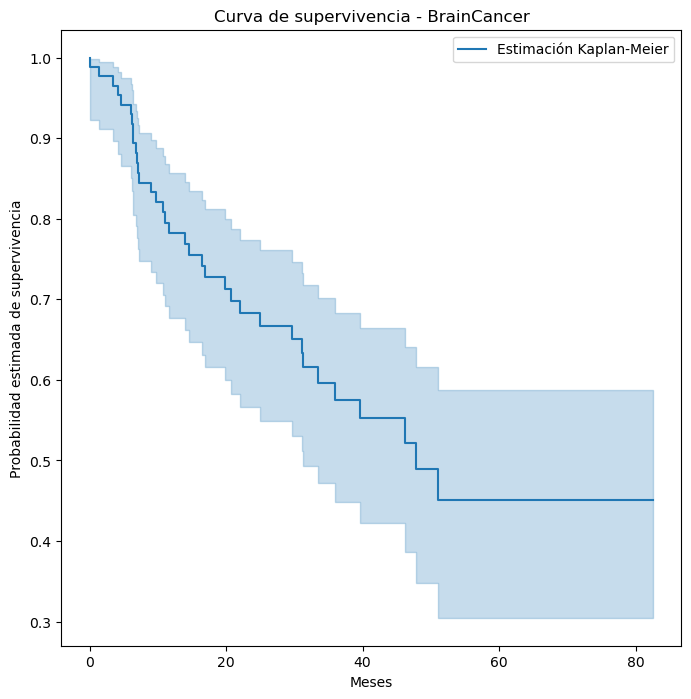

In [6]:
fig, ax = subplots(figsize=(8,8))
km = KaplanMeierFitter()
km_brain = km.fit(BrainCancer['time'], BrainCancer['status'])
km_brain.plot(label='Estimación Kaplan-Meier', ax=ax)
ax.set_xlabel('Meses')
ax.set_ylabel('Probabilidad estimada de supervivencia')
ax.set_title('Curva de supervivencia - BrainCancer');

**Lectura:** el eje $y$ es la probabilidad estimada de seguir vivo más allá del tiempo del eje $x$. La banda sombreada es el intervalo de confianza, que se ensancha a la derecha (hay menos pacientes en riesgo, más incertidumbre).

### 2.2. Curvas estratificadas por sexo

Una pregunta natural: ¿difiere la supervivencia entre hombres y mujeres? Estimamos una curva KM por grupo.

/var/folders/wy/42flyl6d5wl9m3vp2mhsmm6w0000gn/T/ipykernel_11823/3959035321.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for sex, df in BrainCancer.groupby('sex'):


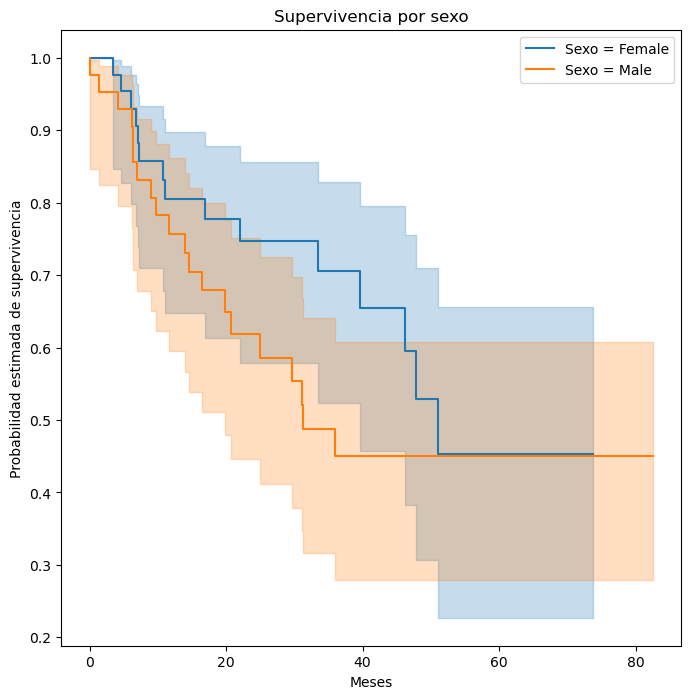

In [7]:
fig, ax = subplots(figsize=(8,8))
by_sex = {}
for sex, df in BrainCancer.groupby('sex'):
    by_sex[sex] = df
    km_sex = km.fit(df['time'], df['status'])
    km_sex.plot(label='Sexo = %s' % sex, ax=ax)
ax.set_xlabel('Meses')
ax.set_ylabel('Probabilidad estimada de supervivencia')
ax.set_title('Supervivencia por sexo');

### 2.3. Test de log-rank

Las curvas se ven distintas, pero ¿la diferencia es **estadísticamente significativa**? El **test de log-rank** es el equivalente, en supervivencia, a un test de diferencia de medias entre grupos. La hipótesis nula es que ambas curvas de supervivencia son iguales.

> Dato útil: el *score test* del modelo de Cox con un único predictor binario coincide exactamente con el estadístico de log-rank.

In [8]:
logrank_test(by_sex['Male']['time'],
             by_sex['Female']['time'],
             by_sex['Male']['status'],
             by_sex['Female']['status'])

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           1.44 0.23      2.12

El $p$-valor es $\approx 0.23$: **no rechazamos** la nula. No hay evidencia de que la supervivencia difiera por sexo.

## 3. Modelo de riesgos proporcionales de Cox

El log-rank compara grupos, pero no nos deja **controlar por covariables** ni usar regresores continuos. Para eso está el modelo de **Cox**, el caballito de batalla de la supervivencia.

Cox modela el *hazard* de cada individuo como:
$$h_i(t) = h_0(t)\,\exp(\beta_1 x_{i1} + \dots + \beta_p x_{ip})$$

- $h_0(t)$ es el *hazard* base, **común a todos** y que queda sin especificar (por eso es *semiparamétrico*: no asume forma para $h_0$).
- El efecto de las covariables es **multiplicativo** sobre el riesgo. Por eso $e^{\beta_j}$ se llama **razón de riesgos** (*hazard ratio*): cuánto multiplica el riesgo un cambio unitario en $x_j$.
- **No tiene intercepto**: queda absorbido en $h_0(t)$. Por eso al armar la matriz de diseño usamos `intercept=False`.

> Lectura económica del coeficiente: $\beta_j > 0$ ⟹ más riesgo ⟹ el evento ocurre **antes** ⟹ menor supervivencia.

### 3.1. Modelo con un único predictor (`sex`)

Replicamos el log-rank, pero ahora vía Cox. `ModelSpec` (de ISLP) arma la matriz de diseño (codifica dummies, etc.); le pasamos `time` y `status` para que `lifelines` sepa cuál es el tiempo y cuál el indicador de evento.

In [9]:
coxph = CoxPHFitter
sex_df = BrainCancer[['time', 'status', 'sex']]
model_df = MS(['time', 'status', 'sex'], intercept=False).fit_transform(sex_df)
cox_fit = coxph().fit(model_df, 'time', 'status')
cox_fit.summary[['coef', 'se(coef)', 'p']]

,coef,se(coef),p
covariate,,,
sex[Male],0.407668,0.342004,0.233262


In [10]:
# Test de razón de verosimilitudes (análogo a un test F global)
cox_fit.log_likelihood_ratio_test()

<lifelines.StatisticalResult: log-likelihood ratio test>
null_distribution = chi squared
  degrees_freedom = 1
        test_name = log-likelihood ratio test

---
 test_statistic    p  -log2(p)
           1.44 0.23      2.12

El $p$-valor coincide con el del log-rank: **sexo no es significativo**. Como anticipamos, el modelo de Cox con un único regresor binario reproduce el log-rank.

### 3.2. Modelo multivariable (todas las covariables)

Acá Cox brilla: ajustamos por todas las covariables simultáneamente. Eliminamos filas con datos faltantes con `dropna()`.

In [11]:
cleaned = BrainCancer.dropna()
all_MS = MS(cleaned.columns, intercept=False)
all_df = all_MS.fit_transform(cleaned)
fit_all = coxph().fit(all_df, 'time', 'status')
fit_all.summary[['coef', 'se(coef)', 'p']]

,coef,se(coef),p
covariate,,,
sex[Male],0.183748,0.360358,0.610119
diagnosis[LG glioma],-1.239530,0.579555,0.032455
diagnosis[Meningioma],-2.154566,0.450524,0.000002
diagnosis[Other],-1.268870,0.617672,0.039949
loc[Supratentorial],0.441195,0.703669,0.530665
ki,-0.054955,0.018314,0.002693
gtv,0.034293,0.022333,0.124661
stereo[SRT],0.177778,0.601578,0.767597


**Interpretación clave (*hazard ratios*):**
- El **índice de Karnofsky** (`ki`) tiene coeficiente negativo y significativo: mejor estado funcional ⟹ menor riesgo ⟹ más supervivencia. Tiene sentido clínico.
- En este *encoding*, la categoría de referencia de `diagnosis` es **HG glioma** (el tumor más agresivo). El coeficiente de **Meningioma** es $\approx -2.15$: como $e^{2.15} \approx 8.6$, el riesgo de un HG glioma es **más de 8 veces** el de un meningioma, manteniendo todo lo demás constante. Los demás diagnósticos también tienen coeficiente negativo (menor riesgo que HG glioma).

### 3.3. Curvas de supervivencia predichas por diagnóstico

Para visualizar el efecto del diagnóstico, predecimos $S(t)$ para cada tipo de tumor, **fijando las demás covariables en un valor representativo** (la moda para categóricas, la media para continuas). Así aislamos el efecto del diagnóstico.

In [12]:
levels = cleaned['diagnosis'].unique()

def representative(series):
    if hasattr(series.dtype, 'categories'):
        return pd.Series.mode(series)
    else:
        return series.mean()

modal_data = cleaned.apply(representative, axis=0)
modal_df = pd.DataFrame([modal_data.iloc[0] for _ in range(len(levels))])
modal_df['diagnosis'] = levels
modal_df

,sex,diagnosis,loc,ki,gtv,stereo,status,time
0,Female,Meningioma,Supratentorial,80.91954,8.687011,SRT,0.402299,27.188621
0,Female,HG glioma,Supratentorial,80.91954,8.687011,SRT,0.402299,27.188621
0,Female,LG glioma,Supratentorial,80.91954,8.687011,SRT,0.402299,27.188621
0,Female,Other,Supratentorial,80.91954,8.687011,SRT,0.402299,27.188621


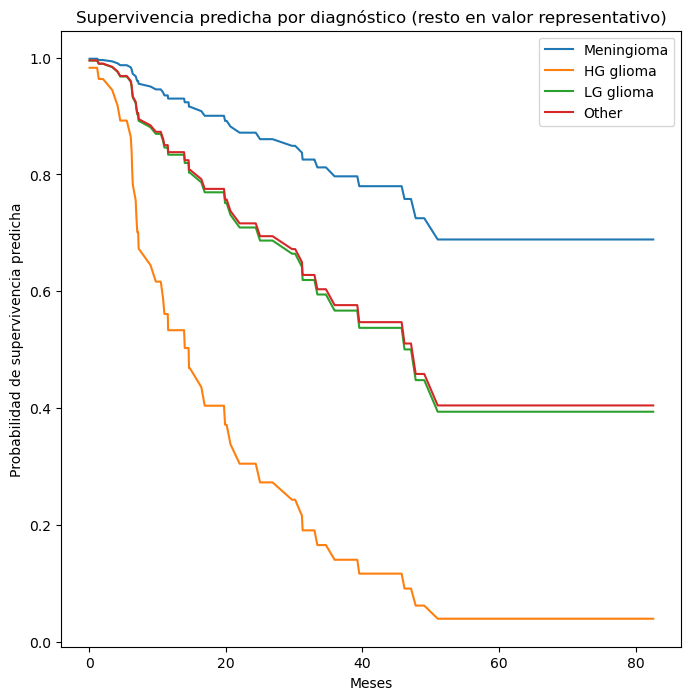

In [13]:
modal_X = all_MS.transform(modal_df)
modal_X.index = levels
predicted_survival = fit_all.predict_survival_function(modal_X)

fig, ax = subplots(figsize=(8,8))
predicted_survival.plot(ax=ax)
ax.set_xlabel('Meses')
ax.set_ylabel('Probabilidad de supervivencia predicha')
ax.set_title('Supervivencia predicha por diagnóstico (resto en valor representativo)');

La curva de **HG glioma** cae mucho más rápido que las demás: coherente con su *hazard ratio* de $\approx 8.6$.

## 4. Datos de `Publication`: una lección sobre confusión

Estos datos registran el **tiempo hasta la publicación** de ensayos clínicos financiados por los NIH. La pregunta de interés: ¿se publican antes los estudios con **resultados positivos** (`posres = 1`)? Esto conecta directo con el sesgo de publicación, un tema clásico en economía empírica.

In [14]:
Publication = load_data('Publication')
Publication.head()

,posres,multi,clinend,mech,sampsize,budget,impact,time,status
0,0,0,1,R01,39876,8.016941,44.016,11.203285,1
1,0,0,1,R01,39876,8.016941,23.494,15.178645,1
2,0,0,1,R01,8171,7.612606,8.391,24.410678,1
3,0,0,1,Contract,24335,11.771928,15.402,2.595483,1
4,0,0,1,Contract,33357,76.517537,16.783,8.607803,1


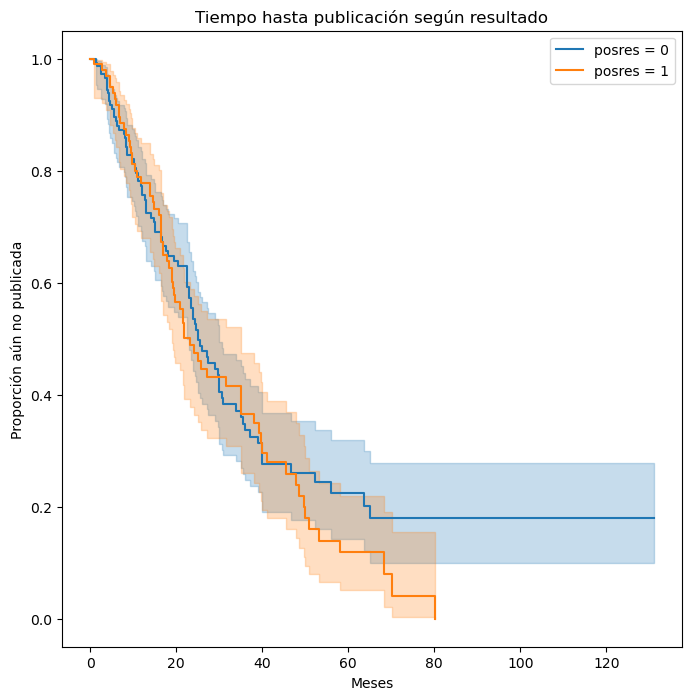

In [15]:
# Curvas KM según el resultado del estudio (positivo vs. no positivo)
fig, ax = subplots(figsize=(8,8))
by_result = {}
for result, df in Publication.groupby('posres'):
    by_result[result] = df
    km_result = km.fit(df['time'], df['status'])
    km_result.plot(label='posres = %d' % result, ax=ax)
ax.set_xlabel('Meses')
ax.set_ylabel('Proporción aún no publicada')
ax.set_title('Tiempo hasta publicación según resultado');

### 4.1. Cox simple: solo `posres`

In [16]:
posres_df = MS(['posres', 'time', 'status'], intercept=False).fit_transform(Publication)
posres_fit = coxph().fit(posres_df, 'time', 'status')
posres_fit.summary[['coef', 'se(coef)', 'p']]

,coef,se(coef),p
covariate,,,
posres,0.148076,0.161625,0.359579


Sin controles, `posres` **no** es significativo ($p \approx 0.36$). Parecería que el resultado no afecta el tiempo a publicación.

### 4.2. Cox ajustado: agregando controles

Agregamos las demás covariables (todas menos `mech`). Esto es exactamente el razonamiento de **variable omitida** que ya conocen de OLS.

In [17]:
model = MS(Publication.columns.drop('mech'), intercept=False)
coxph().fit(model.fit_transform(Publication), 'time', 'status').summary[['coef', 'se(coef)', 'p']]

,coef,se(coef),p
covariate,,,
posres,0.570773,0.175960,1.179610e-03
multi,-0.040860,0.251194,8.707842e-01
clinend,0.546183,0.262000,3.709944e-02
sampsize,0.000005,0.000015,7.507005e-01
budget,0.004386,0.002465,7.515984e-02
impact,0.058318,0.006676,2.426306e-18


Al **controlar** por las otras covariables, `posres` pasa a ser **altamente significativo** ($p \approx 0.001$). Variables confusoras (por ejemplo, lo "importante" del estudio, capturado en parte por el tamaño de muestra) estaban enmascarando el efecto. Mismo problema de **sesgo de variable omitida** de OLS, ahora en un modelo de supervivencia.

## 5. Simulación: datos de un *Call Center*

Para entender de dónde "salen" los datos de supervivencia, los **simulamos** nosotros con parámetros conocidos y después chequeamos si Cox los recupera. El evento es **que el cliente sea atendido**; el tiempo es **cuánto espera en línea**. Si el cliente cuelga antes, su tiempo de espera queda **censurado**.

Simulamos $N = 2000$ llamadas con tres covariables: cantidad de operadores, centro de atención (A/B/C) y franja horaria.

In [18]:
rng = np.random.default_rng(10)
N = 2000
Operators = rng.choice(np.arange(5, 16), N, replace=True)
Center = rng.choice(['A', 'B', 'C'], N, replace=True)
Time = rng.choice(['Morn.', 'After.', 'Even.'], N, replace=True)
D = pd.DataFrame({'Operators': Operators,
                  'Center': pd.Categorical(Center),
                  'Time': pd.Categorical(Time)})
D.head()

,Operators,Center,Time
0,13,C,After.
1,15,A,Even.
2,7,B,Morn.
3,7,C,Morn.
4,13,C,Even.


In [19]:
# Matriz de diseño (sin intercepto): genera dummies de Center y Time
model = MS(['Operators', 'Center', 'Time'], intercept=False)
X = model.fit_transform(D)
X.head()

,Operators,Center[B],Center[C],Time[Even.],Time[Morn.]
0,13,0.0,1.0,0.0,0.0
1,15,0.0,0.0,1.0,0.0
2,7,1.0,0.0,0.0,1.0
3,7,0.0,1.0,0.0,1.0
4,13,0.0,1.0,1.0,0.0


### 5.1. Definimos el "mundo verdadero"

Elegimos los coeficientes verdaderos `true_beta` y una función de *hazard* base. El predictor lineal $X\beta$ entra exponenciado en el *hazard*, igual que en Cox.

In [20]:
true_beta = np.array([0.04, -0.3, 0, 0.2, -0.2])
true_linpred = X.dot(true_beta)

# Hazard base creciente en el tiempo y su acumulado
hazard = lambda t: 1e-5 * t
cum_hazard = lambda t: 1e-5 * t**2 / 2

Por ejemplo, el coeficiente $0.04$ de `Operators` implica que cada operador adicional multiplica el riesgo de ser atendido por $e^{0.04} \approx 1.041$ (un 4% más de "riesgo" de que te atiendan = esperás menos).

In [21]:
# sim_time genera el tiempo del evento dado el predictor lineal y el hazard acumulado
W = np.array([sim_time(l, cum_hazard, rng) for l in true_linpred])
D['Wait time'] = np.clip(W, 0, 1000)

# Censura: el 90% efectivamente es atendido (Failed=1); el 10% cuelga antes (censurado=0)
D['Failed'] = rng.choice([1, 0], N, p=[0.9, 0.1])
D[['Operators', 'Center', 'Time', 'Wait time', 'Failed']].head()

,Operators,Center,Time,Wait time,Failed
0,13,C,After.,525.064979,1
1,15,A,Even.,254.677835,1
2,7,B,Morn.,487.739224,1
3,7,C,Morn.,308.580292,1
4,13,C,Even.,154.174608,1


### 5.2. Curvas de Kaplan-Meier por grupo

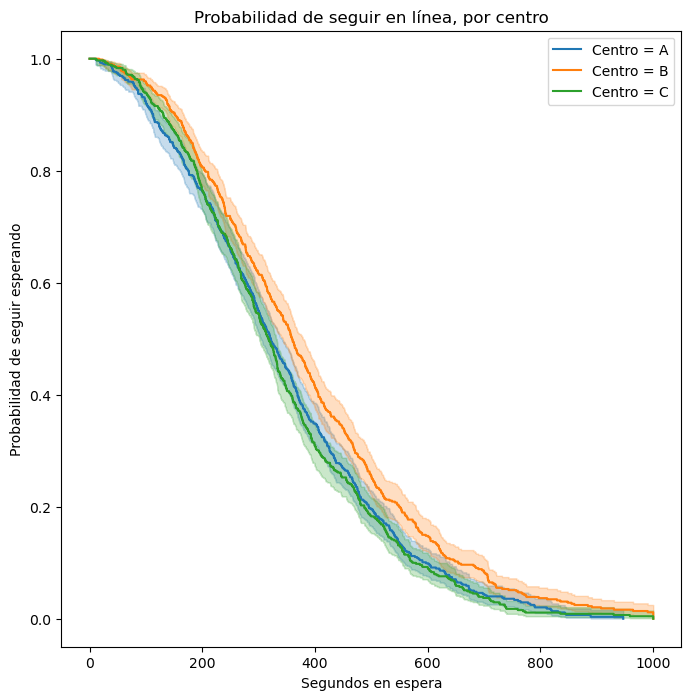

In [22]:
fig, ax = subplots(figsize=(8,8))
by_center = {}
for center, df in D.groupby('Center', observed=True):
    by_center[center] = df
    km_center = km.fit(df['Wait time'], df['Failed'])
    km_center.plot(label='Centro = %s' % center, ax=ax)
ax.set_xlabel('Segundos en espera')
ax.set_ylabel('Probabilidad de seguir esperando')
ax.set_title('Probabilidad de seguir en línea, por centro');

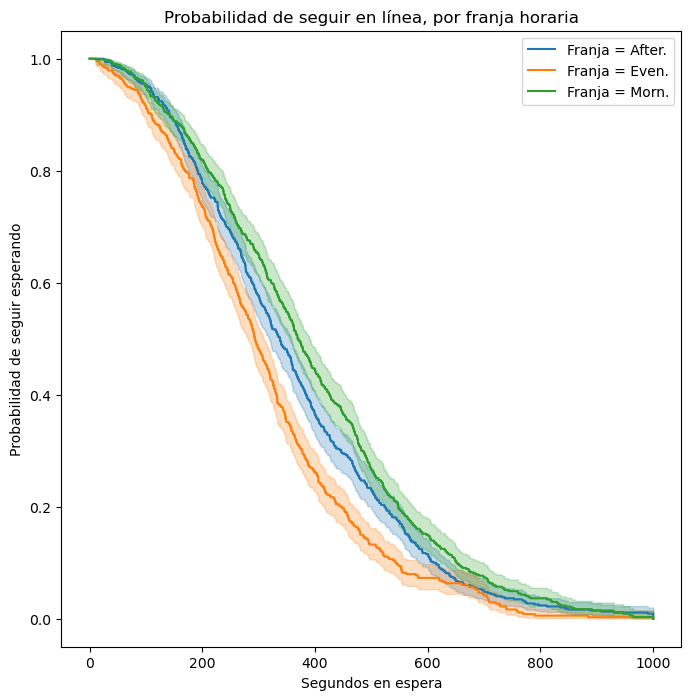

In [23]:
fig, ax = subplots(figsize=(8,8))
by_time = {}
for time, df in D.groupby('Time', observed=True):
    by_time[time] = df
    km_time = km.fit(df['Wait time'], df['Failed'])
    km_time.plot(label='Franja = %s' % time, ax=ax)
ax.set_xlabel('Segundos en espera')
ax.set_ylabel('Probabilidad de seguir esperando')
ax.set_title('Probabilidad de seguir en línea, por franja horaria');

### 5.3. Log-rank multivariado

In [24]:
multivariate_logrank_test(D['Wait time'], D['Center'], D['Failed'])

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
          20.30 <0.005     14.65

In [25]:
multivariate_logrank_test(D['Wait time'], D['Time'], D['Failed'])

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
          49.90 <0.005     35.99

Ambos tests son altamente significativos: tanto el centro como la franja horaria afectan el tiempo de espera. Coherente con que pusimos coeficientes no nulos para esas variables.

### 5.4. Modelo de Cox completo: ¿recuperamos los parámetros?

La prueba de fuego de la simulación: ajustamos Cox con todas las covariables y comparamos los coeficientes estimados con los `true_beta` que usamos para generar los datos.

In [26]:
X_full = MS(D.columns, intercept=False).fit_transform(D)
fit_queuing = coxph().fit(X_full, 'Wait time', 'Failed')
fit_queuing.summary[['coef', 'se(coef)', 'p']]

,coef,se(coef),p
covariate,,,
Operators,0.043934,0.007520,5.143589e-09
Center[B],-0.236060,0.058113,4.864162e-05
Center[C],0.012231,0.057518,8.316096e-01
Time[Even.],0.268845,0.057797,3.294956e-06
Time[Morn.],-0.148217,0.057334,9.733557e-03


In [27]:
# Comparación lado a lado: estimado vs. verdadero
comparacion = fit_queuing.summary[['coef']].copy()
comparacion['true_beta'] = true_beta
comparacion

,coef,true_beta
covariate,,
Operators,0.043934,0.04
Center[B],-0.236060,-0.30
Center[C],0.012231,0.00
Time[Even.],0.268845,0.20
Time[Morn.],-0.148217,-0.20


Los coeficientes estimados quedan **muy cerca** de los verdaderos (ej.: `Operators` $\approx 0.04$, `Center[B]` $\approx -0.3$, `Time[Even.]` $\approx 0.2$). Con $N=2000$ y 90% de eventos observados, Cox recupera bien el "mundo verdadero" a pesar de la censura.

## 6. Cierre

**Lo que vimos hoy:**

| Herramienta | Para qué sirve | Función en Python |
|---|---|---|
| Kaplan-Meier | estimar $S(t)$ sin supuestos | `KaplanMeierFitter().fit()` |
| Log-rank | comparar curvas entre grupos | `logrank_test`, `multivariate_logrank_test` |
| Cox PH | regresión con censura y controles | `CoxPHFitter().fit()` |
| Curvas predichas | visualizar efecto de una covariable | `predict_survival_function()` |
| Simulación | entender el proceso generador | `ISLP.survival.sim_time` |

**Tres ideas para llevarse:**
1. La **censura** es la razón de ser de todo esto: tirar las censuradas sesga; el método las usa parcialmente.
2. El coeficiente de Cox es un **log-*hazard ratio***: $e^{\beta}$ dice cuánto multiplica el riesgo; positivo ⟹ evento más temprano ⟹ menos supervivencia.
3. El **sesgo de variable omitida** que conocen de OLS reaparece en Cox (caso `Publication`): controlar por confusores cambia las conclusiones.

**Ejercicios sugeridos:**
- En `BrainCancer`, ajustar un Cox solo con `ki` y `gtv` e interpretar los *hazard ratios*.
- Verificar el supuesto de riesgos proporcionales con `CoxPHFitter.check_assumptions()`.
- En la simulación, cambiar `true_beta` y el porcentaje de censura y ver cómo se degrada la recuperación de parámetros.

---
*Referencia: ISLP, Capítulo 11 — "Survival Analysis and Censored Data". Lab: https://islp.readthedocs.io/en/latest/labs/Ch11-surv-lab.html*